# EgoTimeQA and Ego4D dataset exploration

This notebook documents my exploration of the EgoTimeQA and Ego4D dataset for IRIS.

# EgoTimeQA Data Preparation

## 1. Project Setup & Configuration
We establish the paths for our input data (the raw annotations) and our output targets. 
* **Annotations:** The QA pairs provided by the EgoTimeQA paper authors.
* **Metadata:** The `ego4d.json` obtained via the CLI (using the `--metadata` flag only).

In [42]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Project Paths
BASE_DIR = Path("/Users/marcushamelink/Developer/ml/IRIS-personal-tests/data")
DATA_DIR = BASE_DIR / "ego4d-downloaded-data"

PATHS = {
    "annotations": BASE_DIR / "EgoTimeQA/unified/annotations.EgoTimeQA.json",
    # Obtained via `ego4d --metadata`
    "metadata": DATA_DIR / "ego4d.json",
    "output_uids": DATA_DIR / "target_clip_uids.txt",
    "output_meta": DATA_DIR / "target_clips_meta.json",
}

print(f"Root: {BASE_DIR}")

Root: /Users/marcushamelink/Developer/ml/IRIS-personal-tests/data


## 2. Data Ingestion & Linking
We need to bridge the gap between the **Research Paper data** and the **Official Ego4D storage**.

The paper provides `video_id`s for their questions, but does not provide file paths or durations. By loading the official Ego4D metadata, we can cross-reference these IDs. 

**Note:** This step confirms that the `video_id` in the EgoTimeQA dataset corresponds to the `clip_uid` in the Ego4D ecosystem (pre-segmented clips), not the full-length raw videos. We create a **Pandas DataFrame** to unify this information for analysis.

In [43]:
# Load source datasets
with open(PATHS["annotations"]) as f:
    egotime_data = json.load(f)

with open(PATHS["metadata"]) as f:
    ego4d_meta = json.load(f)

# Extract unique target IDs from the paper's dataset
target_ids = {item["video_id"] for item in egotime_data if "video_id" in item}

# Build the master dataframe by linking targets to official metadata
matched_data = []
if "clips" in ego4d_meta:
    for clip in ego4d_meta["clips"]:
        # The "Handshake": Check if the official clip exists in our target list
        if clip["clip_uid"] in target_ids:
            matched_data.append({
                "clip_uid": clip["clip_uid"],
                "parent_uid": clip["video_uid"],
                "duration": clip["video_end_sec"] - clip["video_start_sec"],
                "s3_path": clip.get("s3_path", ""),
                "raw_meta": clip,  # Keep full object for downstream usage
            })

df = pd.DataFrame(matched_data)
print(f"Loaded {len(df)} clips (Coverage: {len(df) / len(target_ids):.1%})")
df.head(3)


Loaded 5389 clips (Coverage: 100.0%)


,clip_uid,parent_uid,duration,s3_path,raw_meta
0,00030ae8-e5c4-41ec-a8ea-63548a7665d6,da5bebf7-d7d0-4a1f-aab4-72027b74eb01,480.033333,s3://ego4d-cmu/public/v2/clips/00030ae8-e5c4-4...,{'clip_uid': '00030ae8-e5c4-41ec-a8ea-63548a76...
1,000eba33-8d14-446a-b016-19bd50e9a3b9,ab2bf67b-efc0-4448-8c91-a4cecb29691f,480.000000,,{'clip_uid': '000eba33-8d14-446a-b016-19bd50e9...
2,0014331f-18b1-4200-b4cd-bf55a08aa4fe,a67789f8-3788-4a8d-aba8-9b2c2945d457,300.000000,,{'clip_uid': '0014331f-18b1-4200-b4cd-bf55a08a...


## 3. Exploratory Analysis
Before downloading, we analyze the "cost" of the dataset. We look at the distribution of clip lengths to identify outliers or excessively long clips that might inefficiently consume storage and training time.

count    5389.000000
mean      416.384995
std       137.640422
min       179.933333
25%       300.000000
50%       479.966667
75%       480.000000
max      1200.066667
Name: duration, dtype: float64


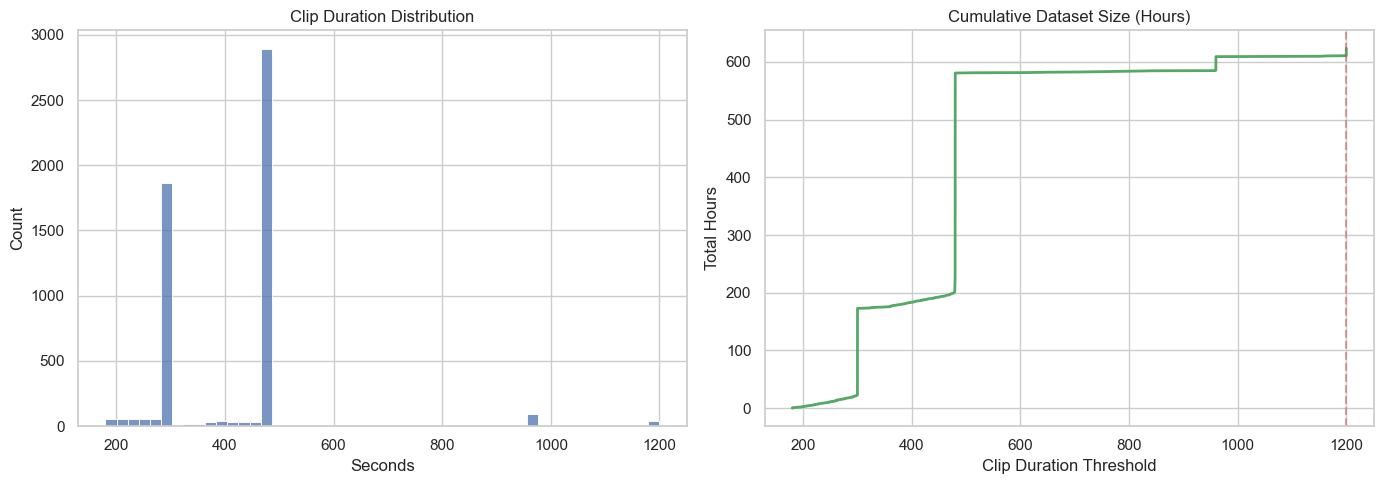

In [44]:
# Quick stats overview
print(df["duration"].describe())

# Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of lengths
sns.histplot(df["duration"], bins=50, color="#4c72b0", ax=ax[0]) # pyright: ignore[reportArgumentType]
ax[0].set_title("Clip Duration Distribution")
ax[0].set_xlabel("Seconds")

# Cumulative Volume (Pareto Chart)
sorted_dur = df.sort_values("duration")["duration"].cumsum() / 3600
ax[1].plot(df.sort_values("duration")["duration"], sorted_dur, color="#55a868", lw=2)
ax[1].set_title("Cumulative Dataset Size (Hours)")
ax[1].set_ylabel("Total Hours")
ax[1].set_xlabel("Clip Duration Threshold")

# Visualizing a 20-minute cut-off
ax[1].axvline(1200, color="r", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()


## 4. Filtering & Export
Based on the analysis above, we create a download list. We filter out extremely long clips (if any) to ensure efficient data loading.

We export two files:
1.  `target_clip_uids.txt`: A clean list of IDs to feed into the `ego4d` CLI.
2.  `target_clips_meta.json`: A JSON file containing the start/end times and metadata for our specific subset, which will be used by our PyTorch/HF DataLoaders later.

In [45]:
# Filter Configuration
MAX_MINUTES = 20
max_seconds = MAX_MINUTES * 60

# Create subset
subset = df[df["duration"] <= max_seconds].copy()
dropped = len(df) - len(subset)

print(f"Filtering > {MAX_MINUTES} mins:")
print(f"- Retained: {len(subset)}")
print(f"- Dropped:  {dropped} ({dropped / len(df):.1%})")

# 1. Export UID list for Ego4D CLI
with open(PATHS["output_uids"], "w") as f:
    f.write("\n".join(subset["clip_uid"]))

# 2. Export Metadata for Dataloader
with open(PATHS["output_meta"], "w") as f:
    json.dump(subset["raw_meta"].tolist(), f, indent=2)

print(f"\nArtifacts saved to {DATA_DIR}")


Filtering > 20 mins:
- Retained: 5365
- Dropped:  24 (0.4%)

Artifacts saved to /Users/marcushamelink/Developer/ml/IRIS-personal-tests/data/ego4d-downloaded-data


## 5. Content & Resource Analysis
Now that we have our subset, we perform two critical checks before committing to the download:

1.  **Storage Estimation:** Since the metadata doesn't always include file size, we estimate the disk footprint using a high-quality bitrate heuristic (~5 Mbps for 1080p video). This helps us allocate sufficient disk space.
2.  **Semantic Distribution:** We analyze the *text* of the questions to understand what actions (e.g., "take", "put", "wash") dominate the dataset. This ensures our subset isn't biased toward a single type of activity.

Estimated Total Size: 1369.57 GB


/var/folders/md/4z68hm9x6ms6x37206mnk7pr0000gn/T/ipykernel_59582/1756683042.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(keywords), palette="viridis", ax=ax[1])


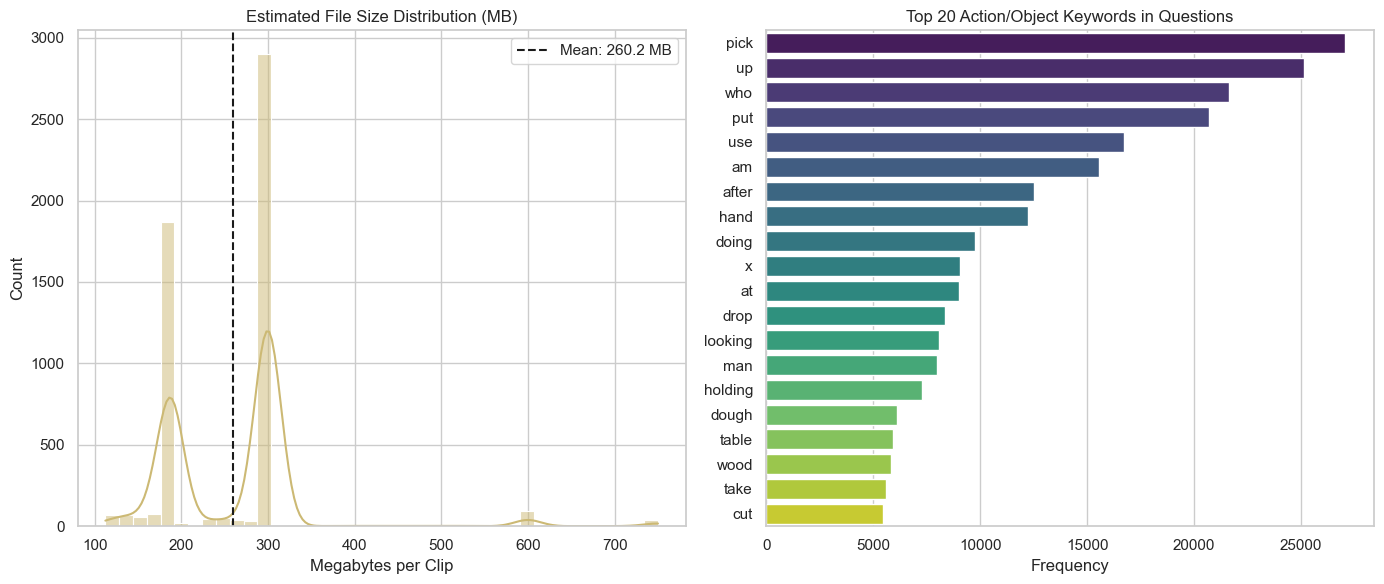

In [46]:
from collections import Counter
import re

# --- 1. Storage Estimation ---
# Heuristic: 5 Mbps (megabits) per second = ~0.625 MB/s
BITRATE_MBPS = 5
MB_PER_SEC = BITRATE_MBPS / 8

df["estimated_size_mb"] = df["duration"] * MB_PER_SEC

print(f"Estimated Total Size: {df['estimated_size_mb'].sum() / 1024:.2f} GB")

# --- 2. Keyword Analysis ---
# We extract verbs/nouns from the questions to see what the "Lab" is doing
all_text = " ".join([
    item["question"].lower() for item in egotime_data if "question" in item
])
# Simple tokenization: remove punctuation and split
words = re.findall(r"\w+", all_text)

# Filter common stop words to find "meaningful" actions
stop_words = {
    "what",
    "where",
    "how",
    "did",
    "i",
    "the",
    "a",
    "an",
    "to",
    "of",
    "in",
    "on",
    "is",
    "do",
    "many",
    "was",
    "with",
    "my",
    "from",
}
meaningful_words = [w for w in words if w not in stop_words]

# Get top 20 keywords
common_keywords = Counter(meaningful_words).most_common(20)

# --- Plotting ---
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot A: File Size Distribution
sns.histplot(df["estimated_size_mb"], bins=40, color="#ccb974", kde=True, ax=ax[0])
ax[0].set_title("Estimated File Size Distribution (MB)")
ax[0].set_xlabel("Megabytes per Clip")
ax[0].axvline(
    df["estimated_size_mb"].mean(),
    color="k",
    linestyle="--",
    label=f"Mean: {df['estimated_size_mb'].mean():.1f} MB",
)
ax[0].legend()

# Plot B: Content Keywords
keywords, counts = zip(*common_keywords)
sns.barplot(x=list(counts), y=list(keywords), palette="viridis", ax=ax[1])
ax[1].set_title("Top 20 Action/Object Keywords in Questions")
ax[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()


## 6. Data Acquisition
We are now ready to download the physical media.

**Strategy:**
* **Dataset:** We select `clips` (pre-segmented MP4s). We **do not** need the `annotations` dataset from the CLI, because we already possess the specialized `annotations.EgoTimeQA.json` provided by the paper authors.
* **Filter:** We apply the `target_clip_uids.txt` generated above to download *only* the relevant files.
* **Metadata:** We skip downloading metadata (`--no-metadata`) since we already fetched and processed it in Step 2.

Copy the command below into your terminal to begin the transfer.

In [ ]:
# --- CLI COMMAND ---
# Run this in your terminal (not in the notebook):
#
# uv run ego4d --output_directory ./ego4d-data \
#   --datasets clips \
#   --video_uid_file ego4d-data/target_clip_uids.txt \
#   --no-metadata \
#   --version v2
